In [1]:
'''
진행순서
1. 데이터 불러오기
2. target 분포 확인
3. EDA
4. Data leakage 제거
5. OneHot 인코딩
6. train/test분리
7. 모델
- Logistic Regression
- RandomForest
- XGBoost
8. threshold tuning
9. lift 분석
'''

'\n진행순서\n1. 데이터 불러오기\n2. target 분포 확인\n3. EDA\n4. Data leakage 제거\n5. OneHot 인코딩\n6. train/test분리\n7. 모델\n- Logistic Regression\n- RandomForest\n- XGBoost\n8. threshold tuning\n9. lift 분석\n'

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns


font_list = [font.name for font in fm.fontManager.ttflist]
font_list

plt.rcParams['font.family'] = 'AppleGothic'
plt.rc('font', family= 'AppleGothic')
print(plt.rcParams['font.family'])

['AppleGothic']


In [6]:
#데이터 불러오기
df = pd.read_csv("bank-additional-full.csv",sep = ";")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [7]:
df.shape

(41188, 21)

In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [9]:
#결측치 확인
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [10]:
#target 분포 확인
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [36]:
df["y"].value_counts(normalize= True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

In [12]:
#정기 예금에 가입한 사람의 비율은 11% -> 데이터 불균형

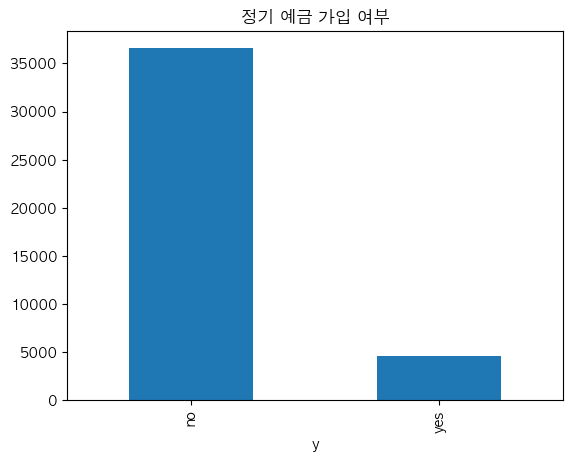

In [13]:
#EDA
import matplotlib.pyplot as plt
df["y"].value_counts().plot(kind = "bar")
plt.title("정기 예금 가입 여부")
plt.show()

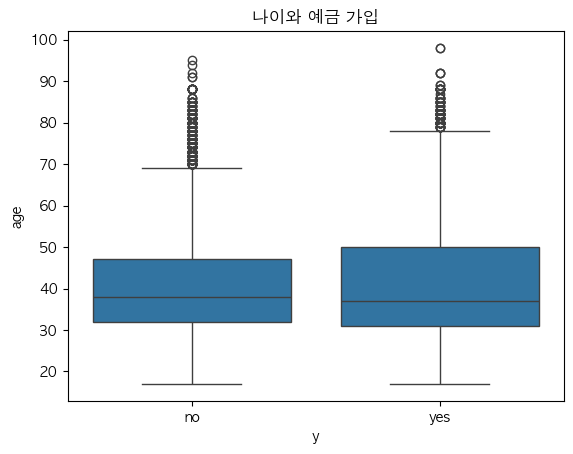

In [15]:
sns.boxplot(x = "y", y= "age", data= df)
plt.title("나이와 예금 가입")
plt.show()

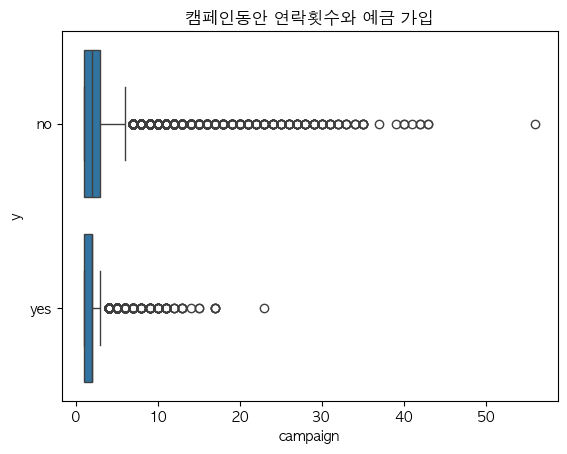

In [27]:
sns.boxplot(x = "campaign", y = "y", data= df)
plt.title("캠페인동안 연락횟수와 예금 가입")
plt.show()

In [28]:
#캠페인동안 연락횟수 많을수록 가입율 떨어짐

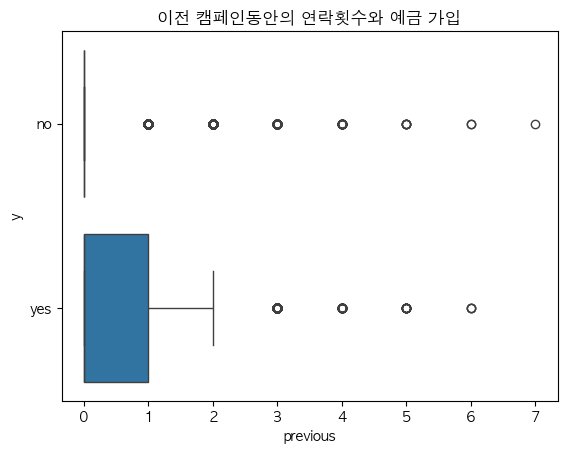

In [25]:
sns.boxplot(x = "previous", y = "y", data= df)
plt.title("이전 캠페인동안의 연락횟수와 예금 가입")
plt.show()

In [26]:
#연락횟수가 많을수록 예금 가입율 적음

In [46]:
df["poutcome"].value_counts(normalize = True)

poutcome
nonexistent    0.863431
failure        0.103234
success        0.033335
Name: proportion, dtype: float64

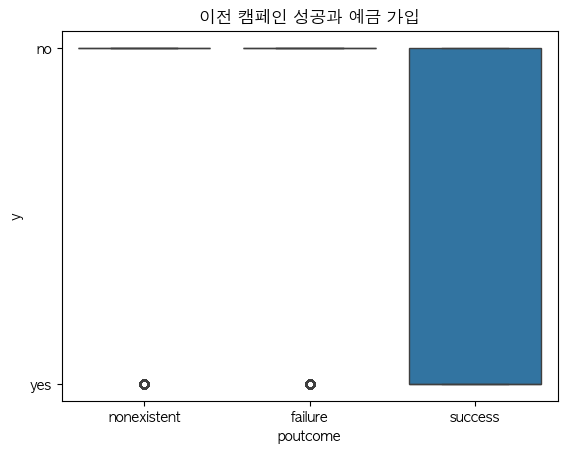

In [21]:
sns.boxplot(x = "poutcome", y = "y", data= df)
plt.title("이전 캠페인 성공과 예금 가입")
plt.show()

In [22]:
# 이전 캠페인 성공시 예금 가입률 올라감

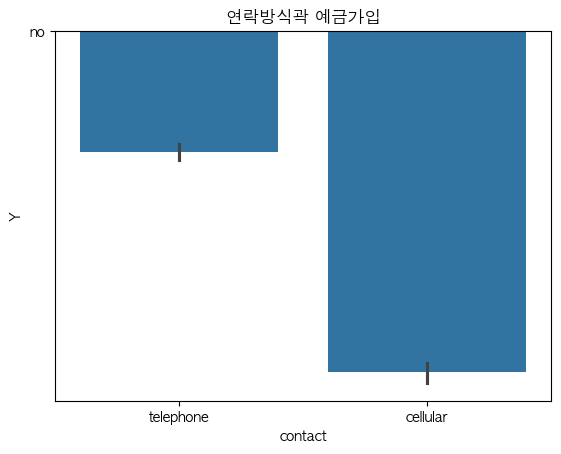

In [34]:
sns.barplot(x="contact", y="y",data = df)
plt.xlabel("contact")
plt.ylabel("Y")
plt.title("연락방식곽 예금가입")
plt.show()

In [35]:
#휴대폰으로 연락했을때 가입률 높음

In [45]:
job_rate = (
    df.groupby("job")["y"]
    .value_counts(normalize=True)
    .unstack()
    .sort_values("yes", ascending=False)
)

job_rate

y,no,yes
job,,
student,0.685714,0.314286
retired,0.747674,0.252326
unemployed,0.857988,0.142012
admin.,0.870274,0.129726
management,0.887825,0.112175
unknown,0.887879,0.112121
technician,0.891740,0.108260
self-employed,0.895144,0.104856
housemaid,0.900000,0.100000


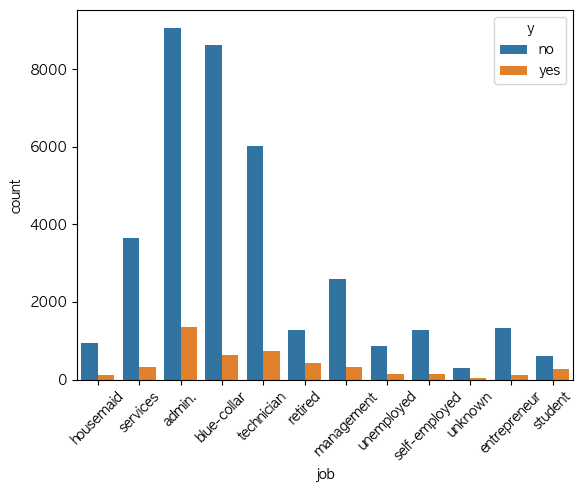

In [42]:
sns.countplot(x="job", hue="y", data=df)
plt.xticks(rotation=45)
plt.show()

In [47]:
#데이터 전처리
df = df.drop("duration",axis =1)

In [48]:
df["y"] = df["y"].map({"yes":1, "no":0})

In [49]:
df.select_dtypes(include = "object").columns

/var/folders/l7/25v5xnr126nbxqgsrrj9qv4r0000gp/T/ipykernel_1879/3078658240.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include = "object").columns


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')

In [50]:
#onehot 인코딩
df = pd.get_dummies(df,drop_first = True)

In [55]:
#feature/target 분리
X = df.drop("y",axis=1)
y = df["y"]

In [56]:
#train/test 분리
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state=42,stratify=y)

In [58]:
#baseline 모델
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train, y_train)

pred = log_model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

Accuracy: 0.8997329448895363
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.68      0.21      0.32       928

    accuracy                           0.90      8238
   macro avg       0.79      0.60      0.63      8238
weighted avg       0.88      0.90      0.88      8238



/Users/kimzaeheon/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [59]:
#Confuison Matrix
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,pred))

[[7218   92]
 [ 734  194]]


In [60]:
#RandomForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(random_state =42,n_estimators=200,n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.58      0.30      0.40       928

    accuracy                           0.90      8238
   macro avg       0.75      0.64      0.67      8238
weighted avg       0.88      0.90      0.88      8238



In [61]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, rf_pred))

[[7111  199]
 [ 648  280]]


In [62]:
#Feature Importance
importance = pd.Series(rf.feature_importances_,index = X_train.columns).sort_values(ascending=False)
importance.head(10)

age                 0.172418
euribor3m           0.125433
campaign            0.087278
nr.employed         0.046779
housing_yes         0.038616
pdays               0.038393
cons.conf.idx       0.027552
loan_yes            0.024722
emp.var.rate        0.023739
poutcome_success    0.023726
dtype: float64

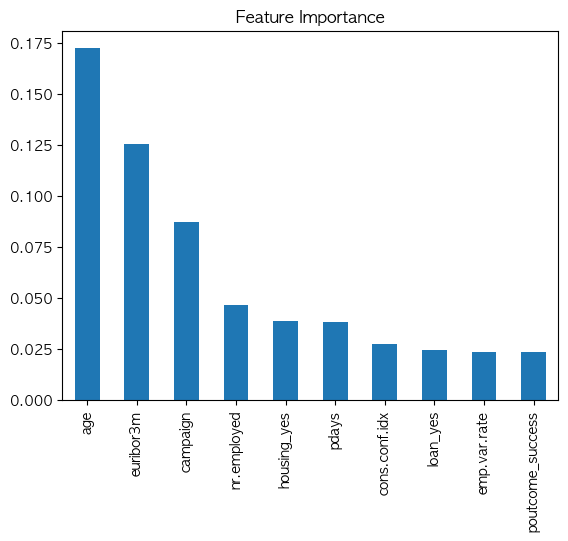

In [63]:
importance.head(10).plot(kind="bar")
plt.title("Feature Importance")
plt.show()

In [66]:
#XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb = XGBClassifier(random_state=42,n_estimators=300,learning_rate=0.05,max_depth=6)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7310
           1       0.66      0.27      0.39       928

    accuracy                           0.90      8238
   macro avg       0.79      0.63      0.67      8238
weighted avg       0.89      0.90      0.88      8238



In [68]:
print(confusion_matrix(y_test,xgb_pred))

[[7178  132]
 [ 673  255]]


In [71]:
#Threshold 최적치 찾기
from sklearn.metrics import precision_score,recall_score
import numpy as np

proba = xgb.predict_proba(X_test)[:,1]
thresholds = np.arange(0.1,0.9,0.05)
result = []

for t in thresholds:
    pred = (proba >= t).astype(int)
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    result.append([t,precision,recall])

for r in result:
    print(r)

[np.float64(0.1), 0.33473906167633105, 0.6842672413793104]
[np.float64(0.15000000000000002), 0.43416102332580886, 0.6217672413793104]
[np.float64(0.20000000000000004), 0.4790365744870651, 0.5786637931034483]
[np.float64(0.25000000000000006), 0.5029585798816568, 0.5495689655172413]
[np.float64(0.30000000000000004), 0.5295454545454545, 0.5021551724137931]
[np.float64(0.3500000000000001), 0.5593451568894953, 0.4418103448275862]
[np.float64(0.40000000000000013), 0.5989672977624785, 0.375]
[np.float64(0.45000000000000007), 0.6363636363636364, 0.3168103448275862]
[np.float64(0.5000000000000001), 0.6589147286821705, 0.27478448275862066]
[np.float64(0.5500000000000002), 0.6807817589576547, 0.2252155172413793]
[np.float64(0.6000000000000002), 0.6733067729083665, 0.18211206896551724]
[np.float64(0.6500000000000001), 0.694300518134715, 0.14439655172413793]
[np.float64(0.7000000000000002), 0.7272727272727273, 0.11206896551724138]
[np.float64(0.7500000000000002), 0.7706422018348624, 0.0905172413793

In [72]:
#최적의 Threshold
#t : 0.25
#precision : 0.50
#recall : 0.54

In [91]:
#Lift 분석
proba = xgb.predict_proba(X_test)[:,1]

lift_df = pd.DataFrame({"proba":proba,"actual":y_test.values})

In [92]:
#확률 기준 정렬
lift_df = lift_df.sort_values("proba", ascending=False)
#10개 구간 나누기
lift_df["decile"] = pd.qcut(lift_df.index,10,labels=False)

#각 구간 가입률
decile_rate = lift_df.groupby("decile")["actual"].mean()

#누적
cum_gain = decile_rate.cumsum()

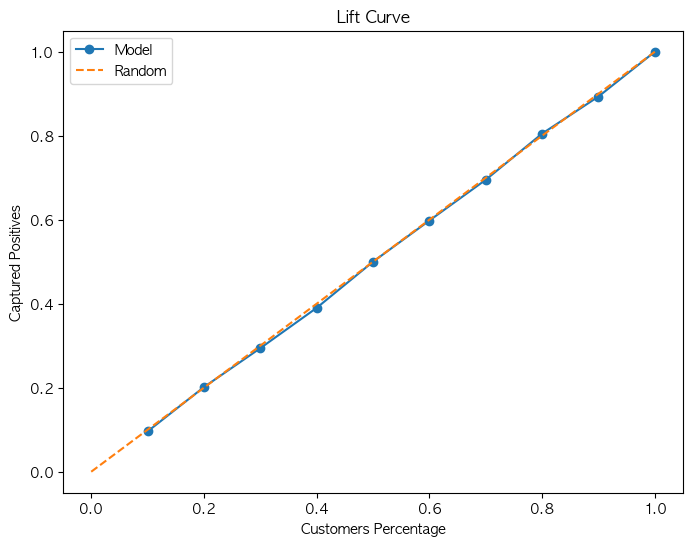

In [93]:
#Lift Curve 시각화
plt.figure(figsize = (8,6))

plt.plot(np.arange(1,11)/10, cum_gain/cum_gain.max(),marker="o",label="Model")
plt.plot([0,1],[0,1],linestyle="--",label="Random")

plt.xlabel("Customers Percentage")
plt.ylabel("Captured Positives")
plt.title("Lift Curve")
plt.legend()

plt.show()

In [94]:
top_10 = lift_df.head(int(len(lift_df)*0.1))
top_10["actual"].mean()

np.float64(0.5443499392466585)

In [95]:
print("Top 10% 가입률:", lift_df.head(int(len(lift_df)*0.1))["actual"].mean())
print("전체 가입률:",lift_df["actual"].mean())

Top 10% 가입률: 0.5443499392466585
전체 가입률: 0.11264870114105366
